# 03 - Regression Models for Popularity

Goal: predict a song's `popularity` score from Spotify audio characteristics. This notebook compares multiple linear regression and degree-2 polynomial regression using train/test MSE.

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
DATA_CLEAN = PROJECT_ROOT / "data" / "processed" / "spotify_tracks_clean.csv"

RANDOM_STATE = 42

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="Set2")
df = pd.read_csv(DATA_CLEAN)
print(df.shape)
display(df.head())

(89741, 23)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,is_explicit,popularity_class
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433,0,High
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500,0,High
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767,0,High
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550,0,High
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217,0,High


## Feature Selection

Identifiers and text metadata are excluded because they do not represent transferable audio characteristics. Genre is included in the linear model as a one-hot encoded business context feature. The polynomial model uses audio/numeric features only because polynomial interactions over all genre dummies would create a very large and less interpretable design matrix.

In [3]:
target = "popularity"
numeric_features = [
    "duration_min", "is_explicit", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "time_signature"
]
categorical_features = ["track_genre"]

X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(71792, 15) (17949, 15)


In [4]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

linear_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("genre", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder)
        ]), categorical_features)
    ]
)

linear_model = Pipeline([
    ("preprocess", linear_preprocess),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)

linear_train_mse = mean_squared_error(y_train, linear_train_pred)
linear_test_mse = mean_squared_error(y_test, linear_test_pred)
print(f"Linear train MSE: {linear_train_mse:.3f}")
print(f"Linear test MSE: {linear_test_mse:.3f}")

Linear train MSE: 283.706
Linear test MSE: 283.750


## Polynomial Regression

Degree 2 is selected because it captures curved relationships and pairwise interactions, such as an optimal range of danceability or energy, without making the feature space too large for this tabular dataset.

In [5]:
X_num = df[numeric_features]
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_num, y, test_size=0.2, random_state=RANDOM_STATE
)

polynomial_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", Ridge(alpha=1.0))
])

polynomial_model.fit(X_train_num, y_train_num)
poly_train_pred = polynomial_model.predict(X_train_num)
poly_test_pred = polynomial_model.predict(X_test_num)

poly_train_mse = mean_squared_error(y_train_num, poly_train_pred)
poly_test_mse = mean_squared_error(y_test_num, poly_test_pred)
print(f"Polynomial train MSE: {poly_train_mse:.3f}")
print(f"Polynomial test MSE: {poly_test_mse:.3f}")

Polynomial train MSE: 389.887
Polynomial test MSE: 389.201


In [6]:
mse_table = pd.DataFrame({
    "model": ["Multiple Linear Regression", "Polynomial Regression degree 2"],
    "train_mse": [linear_train_mse, poly_train_mse],
    "test_mse": [linear_test_mse, poly_test_mse],
    "test_rmse_popularity_points": [np.sqrt(linear_test_mse), np.sqrt(poly_test_mse)],
    "generalization_gap": [linear_test_mse - linear_train_mse, poly_test_mse - poly_train_mse],
})
display(mse_table.round(3))

,model,train_mse,test_mse,test_rmse_popularity_points,generalization_gap
0,Multiple Linear Regression,283.706,283.750,16.845,0.044
1,Polynomial Regression degree 2,389.887,389.201,19.728,-0.685


## Which Features Have the Strongest Effect?

Linear coefficients are interpreted after scaling numeric features. Larger absolute coefficients indicate stronger association with popularity in the fitted linear model, holding other included variables constant.

In [7]:
preprocessor = linear_model.named_steps["preprocess"]
feature_names = preprocessor.get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_

coef_table = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coefficient=lambda x: x["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)
display(coef_table.head(20))

,feature,coefficient,abs_coefficient
72,genre__track_genre_iranian,-38.737928,38.737928
106,genre__track_genre_romance,-37.450894,37.450894
80,genre__track_genre_latin,-32.461991,32.461991
77,genre__track_genre_jazz,-31.473212,31.473212
37,genre__track_genre_detroit-techno,-31.189584,31.189584
26,genre__track_genre_chicago-house,-30.217325,30.217325
79,genre__track_genre_kids,-27.233711,27.233711
29,genre__track_genre_classical,-26.706648,26.706648
55,genre__track_genre_grindcore,-26.222319,26.222319
67,genre__track_genre_idm,-25.859308,25.859308


## Actual vs. Predicted Values

Points near the diagonal line are accurate predictions. Spread around the line represents prediction error in popularity points.

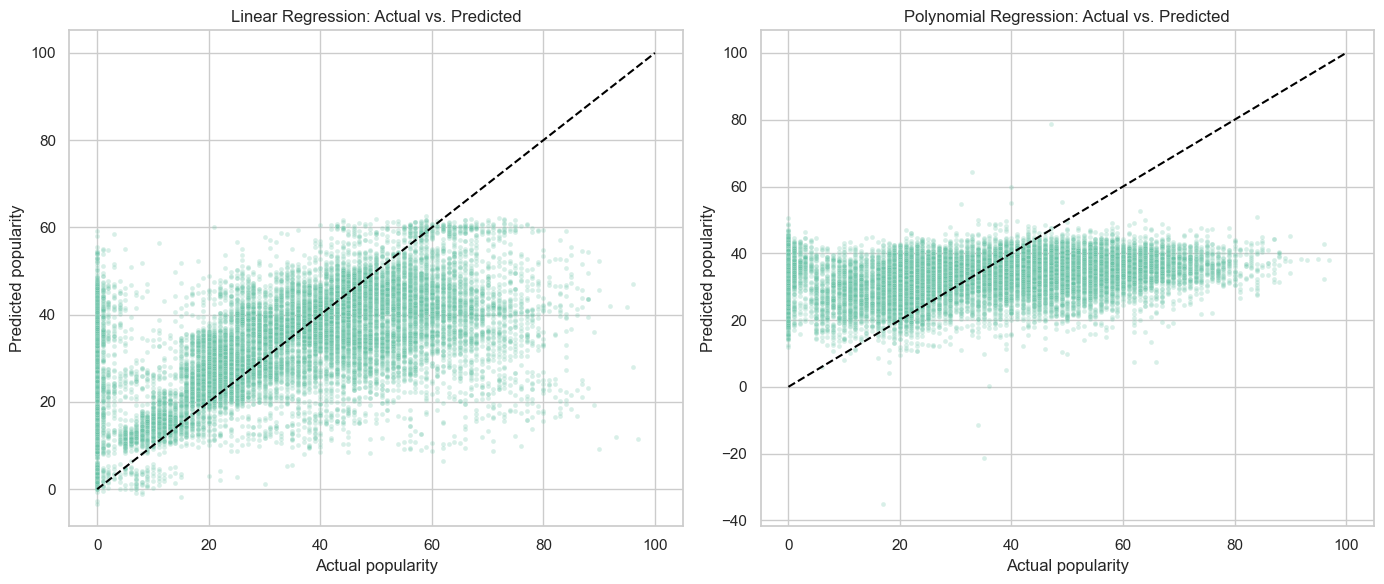

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=y_test, y=linear_test_pred, alpha=0.25, s=12, ax=axes[0])
axes[0].plot([0, 100], [0, 100], color="black", linestyle="--")
axes[0].set_title("Linear Regression: Actual vs. Predicted")
axes[0].set_xlabel("Actual popularity")
axes[0].set_ylabel("Predicted popularity")

sns.scatterplot(x=y_test_num, y=poly_test_pred, alpha=0.25, s=12, ax=axes[1])
axes[1].plot([0, 100], [0, 100], color="black", linestyle="--")
axes[1].set_title("Polynomial Regression: Actual vs. Predicted")
axes[1].set_xlabel("Actual popularity")
axes[1].set_ylabel("Predicted popularity")

plt.tight_layout()
plt.show()

In [9]:
best_model = mse_table.sort_values("test_mse").iloc[0]
overfit_notes = []
for _, row in mse_table.iterrows():
    if row["generalization_gap"] > 25:
        overfit_notes.append(f"{row['model']} shows a notable train/test gap.")
    else:
        overfit_notes.append(f"{row['model']} has a modest train/test gap.")

print("Interpretation:")
print(f"- Best test MSE model: {best_model['model']} with MSE {best_model['test_mse']:.2f}.")
print(f"- The RMSE is about {best_model['test_rmse_popularity_points']:.2f} popularity points.")
print("- In business terms, this error means the model is better for estimating broad popularity potential than for guaranteeing an exact Spotify popularity score.")
for note in overfit_notes:
    print("-", note)
print("- Audio features influence popularity, but large residual spread suggests artist, playlist, market, recency, and promotion effects are also important.")

Interpretation:
- Best test MSE model: Multiple Linear Regression with MSE 283.75.
- The RMSE is about 16.84 popularity points.
- In business terms, this error means the model is better for estimating broad popularity potential than for guaranteeing an exact Spotify popularity score.
- Multiple Linear Regression has a modest train/test gap.
- Polynomial Regression degree 2 has a modest train/test gap.
- Audio features influence popularity, but large residual spread suggests artist, playlist, market, recency, and promotion effects are also important.


## Executive Conclusion

The regression models provide a baseline for estimating expected popularity from audio characteristics. If the polynomial model has lower test MSE without a large generalization gap, nonlinear effects are useful. If the linear model is competitive, Spotify should prefer it for interpretability. In either case, predicted popularity should support discovery and catalog prioritization rather than replace business judgment.